
Running Permutation Test for 30 minutes:
Observed Difference: 12.450102460510806
P-value: 0.3316


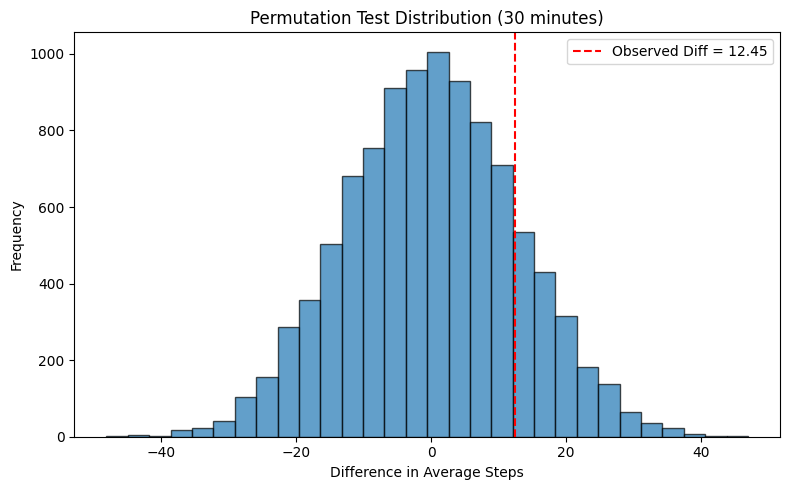


Running Permutation Test for 60 minutes:
Observed Difference: 21.516452231756716
P-value: 0.3112


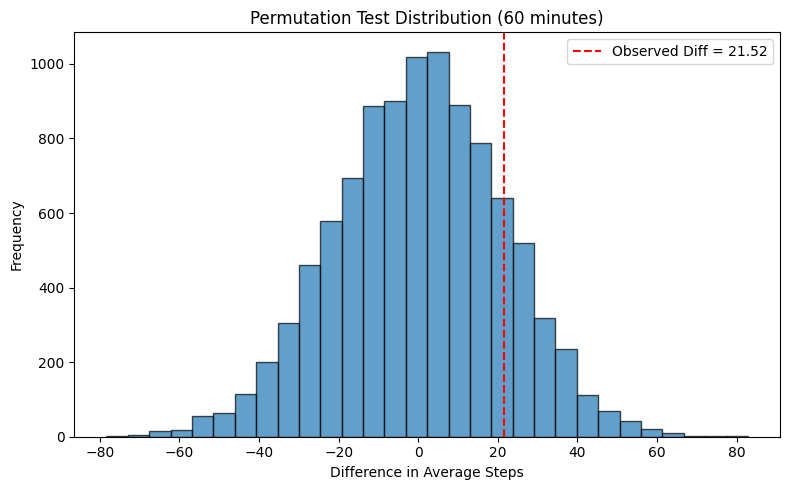


Running Permutation Test for 120 minutes:
Observed Difference: 52.71614360763601
P-value: 0.1376


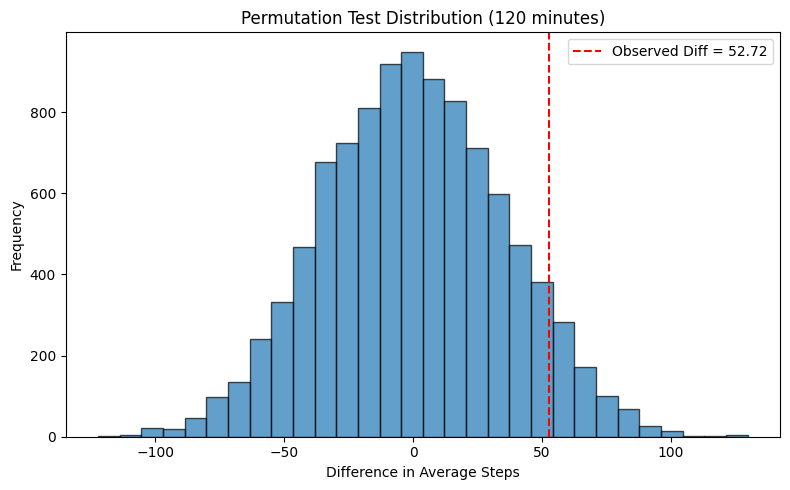

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to perform permutation test
def permutation_test(data_send, data_no_send, num_permutations=10000):
    observed_diff = np.mean(data_send) - np.mean(data_no_send)
    combined = np.concatenate([data_send, data_no_send])
    perm_diffs = []

    for _ in range(num_permutations):
        np.random.shuffle(combined)
        perm_send = combined[:len(data_send)]
        perm_no_send = combined[len(data_send):]
        perm_diff = np.mean(perm_send) - np.mean(perm_no_send)
        perm_diffs.append(perm_diff)

    p_value = np.sum(np.abs(perm_diffs) >= np.abs(observed_diff)) / num_permutations
    return observed_diff, p_value, perm_diffs

# Run permutation test for 30, 60, and 120 minutes
def run_permutation_tests(comparison_df, time_label):
    print(f"\nRunning Permutation Test for {time_label} minutes:")
    
    # Extract sent and unsent data
    data_send = comparison_df[f'jbsteps{time_label}_send'].dropna()
    data_no_send = comparison_df[f'jbsteps{time_label}_no_send'].dropna()
    
    # Perform permutation test
    observed_diff, p_value, perm_diffs = permutation_test(data_send, data_no_send)
    
    # Print results
    print(f"Observed Difference: {observed_diff}")
    print(f"P-value: {p_value}")
    
    # Plot permutation test result
    plt.figure(figsize=(8, 5))
    plt.hist(perm_diffs, bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(observed_diff, color='red', linestyle='--', label=f'Observed Diff = {observed_diff:.2f}')
    plt.title(f'Permutation Test Distribution ({time_label} minutes)')
    plt.xlabel('Difference in Average Steps')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Load the datasets (same as before)
file_path_send = '../data/modified_data/Cleaned Dataset.csv'  
file_path_no_send = '../data/modified_data/Cleaned Unsent Dataset.csv'  

send_data = pd.read_csv(file_path_send)
no_send_data = pd.read_csv(file_path_no_send)

# Clean the column names by stripping leading/trailing spaces
send_data.columns = send_data.columns.str.strip()
no_send_data.columns = no_send_data.columns.str.strip()

# Convert 'sugg.decision.utime' to datetime format
send_data['sugg.decision.utime'] = pd.to_datetime(send_data['sugg.decision.utime'])
no_send_data['sugg.decision.utime'] = pd.to_datetime(no_send_data['sugg.decision.utime'])

# Fill NaN values in 'decision.index.nogap' with 0
send_data['decision.index.nogap'] = send_data['decision.index.nogap'].fillna(0)
no_send_data['decision.index.nogap'] = no_send_data['decision.index.nogap'].fillna(0)

# Calculate the tracked day as decision.index.nogap // 5 to integer round down
send_data['tracked_day'] = (send_data['decision.index.nogap'] // 5).astype(int)
no_send_data['tracked_day'] = (no_send_data['decision.index.nogap'] // 5).astype(int)

# Filter to only include the first 42 days
send_data = send_data[send_data['tracked_day'] <= 42]
no_send_data = no_send_data[no_send_data['tracked_day'] <= 42]

# Group by the tracked day and calculate the average step counts for jbsteps30, jbsteps60, and jbsteps120 for both send and no send data
# For 30 minutes
send_avg_steps_30 = send_data.groupby('tracked_day')['jbsteps30'].mean().reset_index()
no_send_avg_steps_30 = no_send_data.groupby('tracked_day')['jbsteps30'].mean().reset_index()

# For 60 minutes
send_avg_steps_60 = send_data.groupby('tracked_day')['jbsteps60'].mean().reset_index()
no_send_avg_steps_60 = no_send_data.groupby('tracked_day')['jbsteps60'].mean().reset_index()

# For 120 minutes
send_avg_steps_120 = send_data.groupby('tracked_day')['jbsteps120'].mean().reset_index()
no_send_avg_steps_120 = no_send_data.groupby('tracked_day')['jbsteps120'].mean().reset_index()

# Merge the data into a single DataFrame for comparison
comparison_df_30 = pd.merge(send_avg_steps_30, no_send_avg_steps_30, on='tracked_day', how='outer', suffixes=('_send', '_no_send'))
comparison_df_60 = pd.merge(send_avg_steps_60, no_send_avg_steps_60, on='tracked_day', how='outer', suffixes=('_send', '_no_send'))
comparison_df_120 = pd.merge(send_avg_steps_120, no_send_avg_steps_120, on='tracked_day', how='outer', suffixes=('_send', '_no_send'))

# Run permutation tests for 30, 60, and 120 minutes
run_permutation_tests(comparison_df_30, 30)
run_permutation_tests(comparison_df_60, 60)
run_permutation_tests(comparison_df_120, 120)



Running Permutation Test for Standard Deviation Difference (30 minutes):
Observed Difference in Std: -17.659828543815223
P-value: 0.0834


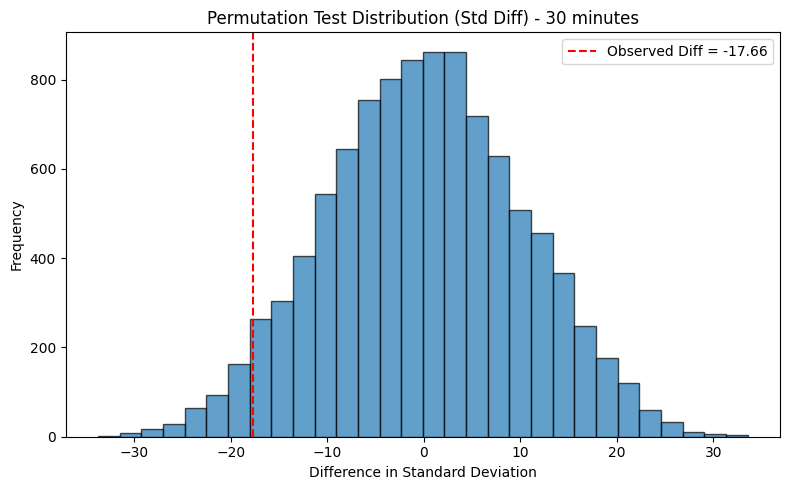


Running Permutation Test for Standard Deviation Difference (60 minutes):
Observed Difference in Std: -31.872671602140983
P-value: 0.0152


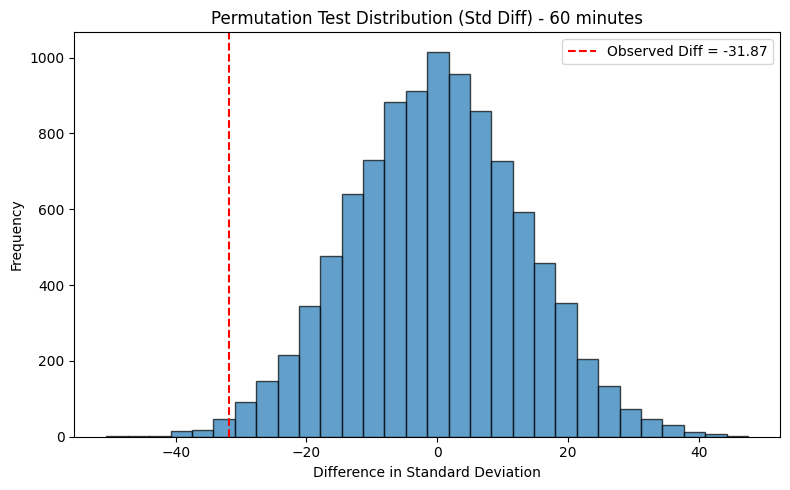


Running Permutation Test for Standard Deviation Difference (120 minutes):
Observed Difference in Std: -15.902306594927069
P-value: 0.5459


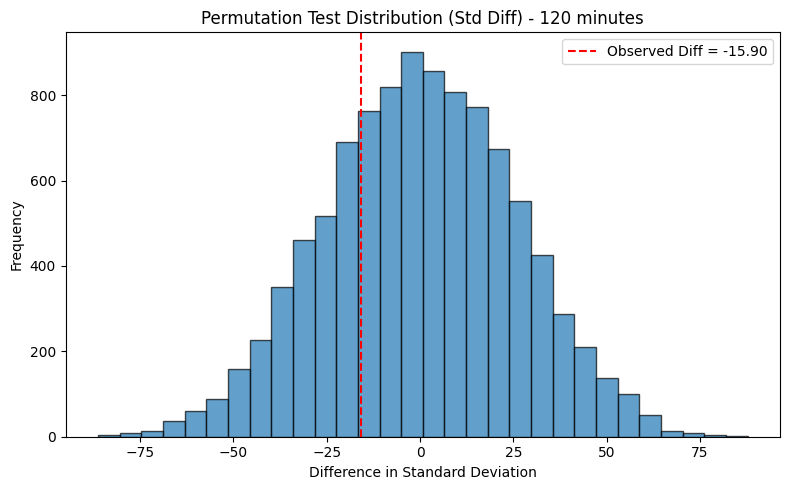

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to perform permutation test on standard deviations
def permutation_test_std(data_send, data_no_send, num_permutations=10000):
    observed_diff_std = np.std(data_send) - np.std(data_no_send)
    combined = np.concatenate([data_send, data_no_send])
    perm_diffs_std = []

    for _ in range(num_permutations):
        np.random.shuffle(combined)
        perm_send = combined[:len(data_send)]
        perm_no_send = combined[len(data_send):]
        perm_diff_std = np.std(perm_send) - np.std(perm_no_send)
        perm_diffs_std.append(perm_diff_std)

    p_value = np.sum(np.abs(perm_diffs_std) >= np.abs(observed_diff_std)) / num_permutations
    return observed_diff_std, p_value, perm_diffs_std

# Run permutation test for 30, 60, and 120 minutes (standard deviation)
def run_permutation_tests_std(comparison_df, time_label):
    print(f"\nRunning Permutation Test for Standard Deviation Difference ({time_label} minutes):")
    
    # Extract sent and unsent data
    data_send = comparison_df[f'jbsteps{time_label}_send'].dropna()
    data_no_send = comparison_df[f'jbsteps{time_label}_no_send'].dropna()
    
    # Perform permutation test on standard deviations
    observed_diff_std, p_value, perm_diffs_std = permutation_test_std(data_send, data_no_send)
    
    # Print results
    print(f"Observed Difference in Std: {observed_diff_std}")
    print(f"P-value: {p_value}")
    
    # Plot permutation test result
    plt.figure(figsize=(8, 5))
    plt.hist(perm_diffs_std, bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(observed_diff_std, color='red', linestyle='--', label=f'Observed Diff = {observed_diff_std:.2f}')
    plt.title(f'Permutation Test Distribution (Std Diff) - {time_label} minutes')
    plt.xlabel('Difference in Standard Deviation')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Load the datasets (same steps as before)
file_path_send = '../data/modified_data/Cleaned Dataset.csv'  
file_path_no_send = '../data/modified_data/Cleaned Unsent Dataset.csv'  

send_data = pd.read_csv(file_path_send)
no_send_data = pd.read_csv(file_path_no_send)

# Clean the column names by stripping leading/trailing spaces
send_data.columns = send_data.columns.str.strip()
no_send_data.columns = no_send_data.columns.str.strip()

# Convert 'sugg.decision.utime' to datetime format
send_data['sugg.decision.utime'] = pd.to_datetime(send_data['sugg.decision.utime'])
no_send_data['sugg.decision.utime'] = pd.to_datetime(no_send_data['sugg.decision.utime'])

# Fill NaN values in 'decision.index.nogap' with 0
send_data['decision.index.nogap'] = send_data['decision.index.nogap'].fillna(0)
no_send_data['decision.index.nogap'] = no_send_data['decision.index.nogap'].fillna(0)

# Calculate the tracked day as decision.index.nogap // 5 to integer round down
send_data['tracked_day'] = (send_data['decision.index.nogap'] // 5).astype(int)
no_send_data['tracked_day'] = (no_send_data['decision.index.nogap'] // 5).astype(int)

# Filter to only include the first 42 days
send_data = send_data[send_data['tracked_day'] <= 42]
no_send_data = no_send_data[no_send_data['tracked_day'] <= 42]

# Group by the tracked day and calculate the average step counts for jbsteps30, jbsteps60, and jbsteps120 for both send and no send data
# For 30 minutes
send_avg_steps_30 = send_data.groupby('tracked_day')['jbsteps30'].mean().reset_index()
no_send_avg_steps_30 = no_send_data.groupby('tracked_day')['jbsteps30'].mean().reset_index()

# For 60 minutes
send_avg_steps_60 = send_data.groupby('tracked_day')['jbsteps60'].mean().reset_index()
no_send_avg_steps_60 = no_send_data.groupby('tracked_day')['jbsteps60'].mean().reset_index()

# For 120 minutes
send_avg_steps_120 = send_data.groupby('tracked_day')['jbsteps120'].mean().reset_index()
no_send_avg_steps_120 = no_send_data.groupby('tracked_day')['jbsteps120'].mean().reset_index()

# Merge the data into a single DataFrame for comparison
comparison_df_30 = pd.merge(send_avg_steps_30, no_send_avg_steps_30, on='tracked_day', how='outer', suffixes=('_send', '_no_send'))
comparison_df_60 = pd.merge(send_avg_steps_60, no_send_avg_steps_60, on='tracked_day', how='outer', suffixes=('_send', '_no_send'))
comparison_df_120 = pd.merge(send_avg_steps_120, no_send_avg_steps_120, on='tracked_day', how='outer', suffixes=('_send', '_no_send'))

# Run permutation tests for standard deviations at 30, 60, and 120 minutes
run_permutation_tests_std(comparison_df_30, 30)
run_permutation_tests_std(comparison_df_60, 60)
run_permutation_tests_std(comparison_df_120, 120)



Weibull Fit Test Results for 30 minutes:
Shape: 0.018032828846741414, Scale: 5.581480410209163e-19
K-S Test Statistic: 0.5697547378406487
P-value: 0.0


/Users/jacksoncamp/Desktop/CornellTech/ORIE 5160/ORIE-5160-Midterm-Project/.venv/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2581: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


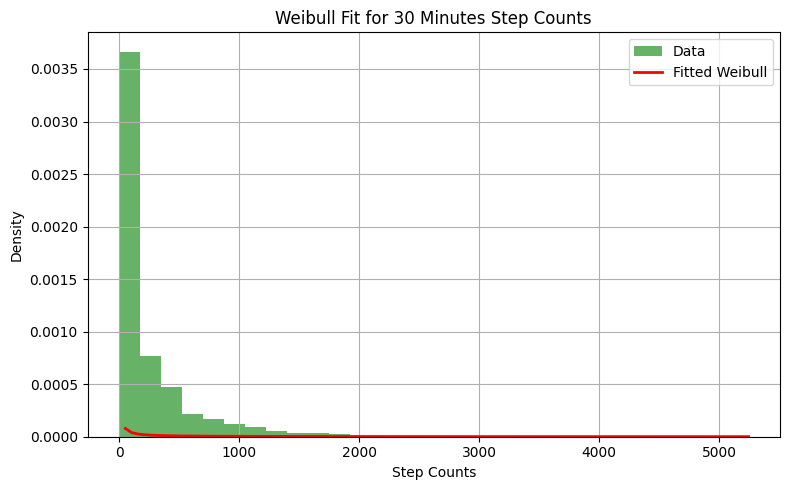


Weibull Fit Test Results for 60 minutes:
Shape: 0.8003856088370509, Scale: 420.34955411575686
K-S Test Statistic: 0.1675249924265374
P-value: 1.909288764606814e-81


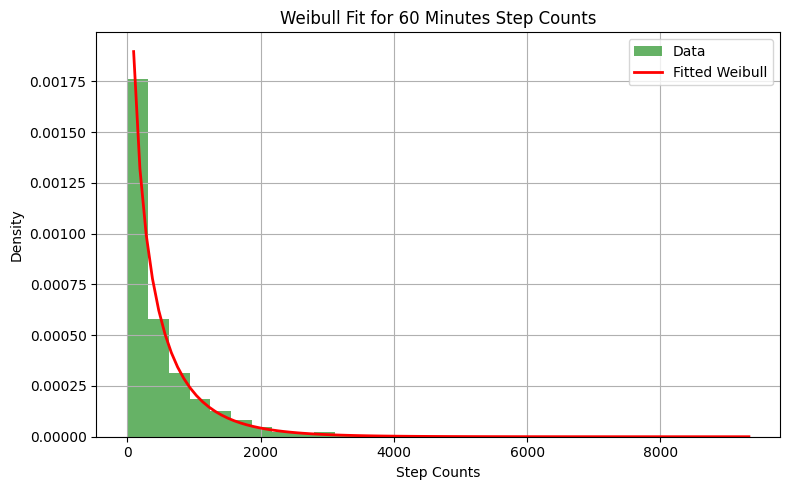


Weibull Fit Test Results for 120 minutes:
Shape: 0.9205963420848973, Scale: 1010.143600564515
K-S Test Statistic: 0.049681914571342016
P-value: 1.607334141109699e-07


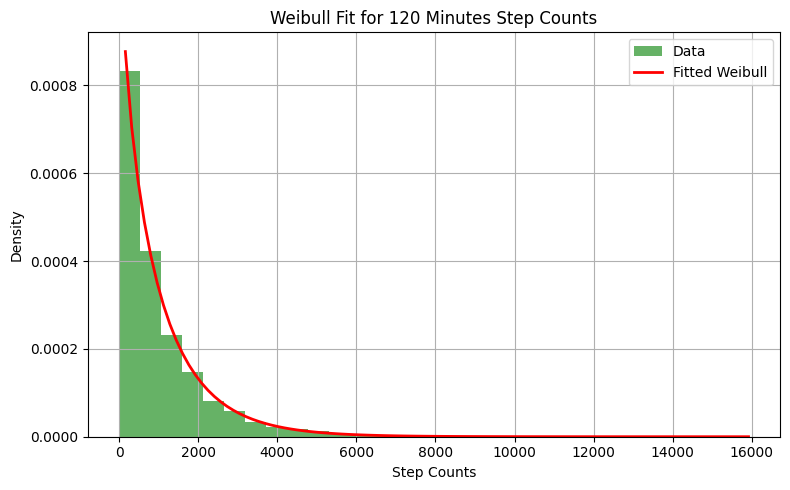

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min, kstest

# Function to test if the data fits a Weibull distribution
def test_weibull_fit(data, time_label):
    # Fit a Weibull distribution to the data
    params = weibull_min.fit(data, floc=0)  # Fit the Weibull with a location parameter fixed at 0
    shape, loc, scale = params
    
    # Perform the Kolmogorov-Smirnov test
    d_stat, p_value = kstest(data, 'weibull_min', args=(shape, loc, scale))
    
    # Print the results
    print(f"\nWeibull Fit Test Results for {time_label} minutes:")
    print(f"Shape: {shape}, Scale: {scale}")
    print(f"K-S Test Statistic: {d_stat}")
    print(f"P-value: {p_value}")
    
    # Plot the histogram of the data and the fitted Weibull distribution
    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=30, density=True, alpha=0.6, color='g', label='Data')
    
    # Plot the Weibull PDF
    x = np.linspace(min(data), max(data), 100)
    plt.plot(x, weibull_min.pdf(x, shape, loc, scale), 'r-', lw=2, label='Fitted Weibull')
    plt.title(f'Weibull Fit for {time_label} Minutes Step Counts')
    plt.xlabel('Step Counts')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Load the datasets (same as before)
file_path_send = '../data/modified_data/Cleaned Dataset_V2.csv'  
file_path_no_send = '../data/modified_data/Cleaned Unsent Dataset_V2.csv'  

send_data = pd.read_csv(file_path_send)
no_send_data = pd.read_csv(file_path_no_send)

# Clean the column names by stripping leading/trailing spaces
send_data.columns = send_data.columns.str.strip()
no_send_data.columns = no_send_data.columns.str.strip()



# Run Weibull fit test for 30, 60, and 120 minutes
test_weibull_fit(send_data["jbsteps30"], 30)
test_weibull_fit(send_data["jbsteps60"], 60)
test_weibull_fit(send_data["jbsteps120"], 120)



Exponential Fit Test Results for 30 minutes:
Location: 0.0, Scale (1/lambda): 250.23508027870344
K-S Test Statistic: 0.32232656770675555
P-value: 1.1213183726678182e-305


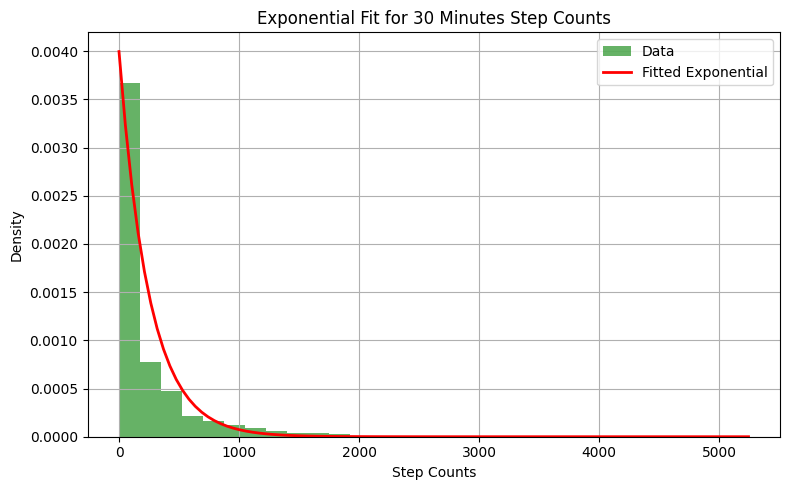


Exponential Fit Test Results for 60 minutes:
Location: 0.0, Scale (1/lambda): 521.6131475310511
K-S Test Statistic: 0.1675249924265374
P-value: 1.909288764606814e-81


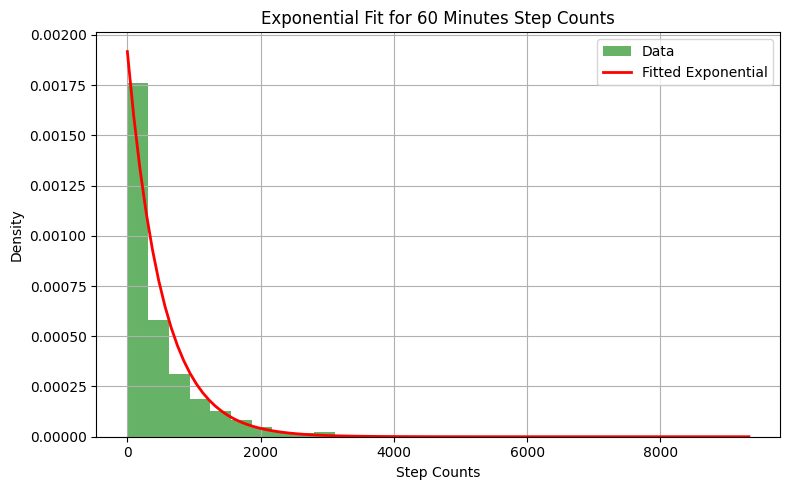


Exponential Fit Test Results for 120 minutes:
Location: 0.0, Scale (1/lambda): 1061.900333232354
K-S Test Statistic: 0.05413993231483663
P-value: 7.520497354422841e-09


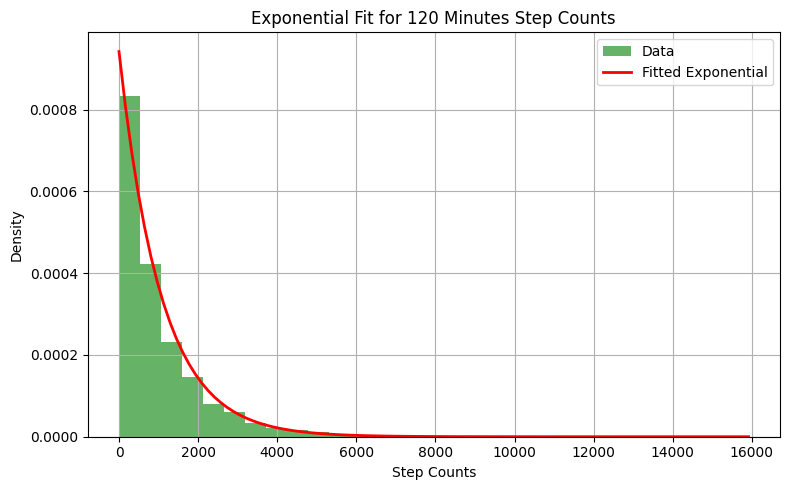

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, kstest

# Function to test if the data fits an Exponential distribution
def test_exponential_fit(data, time_label):
    # Fit an Exponential distribution to the data
    params = expon.fit(data, floc=0)  # Fit the Exponential with location parameter fixed at 0
    loc, scale = params
    
    # Perform the Kolmogorov-Smirnov test
    d_stat, p_value = kstest(data, 'expon', args=(loc, scale))
    
    # Print the results
    print(f"\nExponential Fit Test Results for {time_label} minutes:")
    print(f"Location: {loc}, Scale (1/lambda): {scale}")
    print(f"K-S Test Statistic: {d_stat}")
    print(f"P-value: {p_value}")
    
    # Plot the histogram of the data and the fitted Exponential distribution
    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=30, density=True, alpha=0.6, color='g', label='Data')
    
    # Plot the Exponential PDF
    x = np.linspace(min(data), max(data), 100)
    plt.plot(x, expon.pdf(x, loc, scale), 'r-', lw=2, label='Fitted Exponential')
    plt.title(f'Exponential Fit for {time_label} Minutes Step Counts')
    plt.xlabel('Step Counts')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Load the datasets
file_path_send = '../data/modified_data/Cleaned Dataset_V2.csv'  
file_path_no_send = '../data/modified_data/Cleaned Unsent Dataset_V2.csv'  

send_data = pd.read_csv(file_path_send)
no_send_data = pd.read_csv(file_path_no_send)

# Clean the column names by stripping leading/trailing spaces
send_data.columns = send_data.columns.str.strip()
no_send_data.columns = no_send_data.columns.str.strip()

# Drop NaN values from the columns before fitting
jbsteps30 = send_data["jbsteps30"].dropna()
jbsteps60 = send_data["jbsteps60"].dropna()
jbsteps120 = send_data["jbsteps120"].dropna()

# Run Exponential fit test for 30, 60, and 120 minutes
test_exponential_fit(jbsteps30, 30)
test_exponential_fit(jbsteps60, 60)
test_exponential_fit(jbsteps120, 120)



Running Permutation Test for Lambda Difference (30 minutes):
Observed Difference in Lambda: 12.450102460510806
P-value: 0.3277


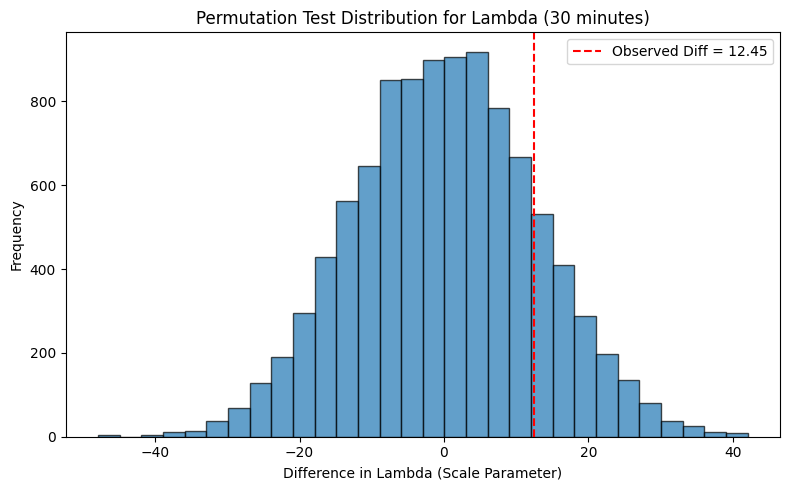


Running Permutation Test for Lambda Difference (60 minutes):
Observed Difference in Lambda: 21.516452231756716
P-value: 0.3182


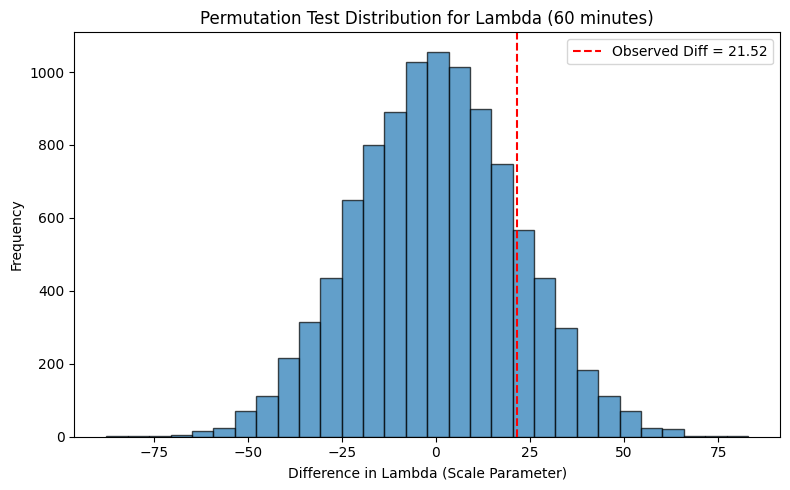


Running Permutation Test for Lambda Difference (120 minutes):
Observed Difference in Lambda: 52.71614360763601
P-value: 0.1395


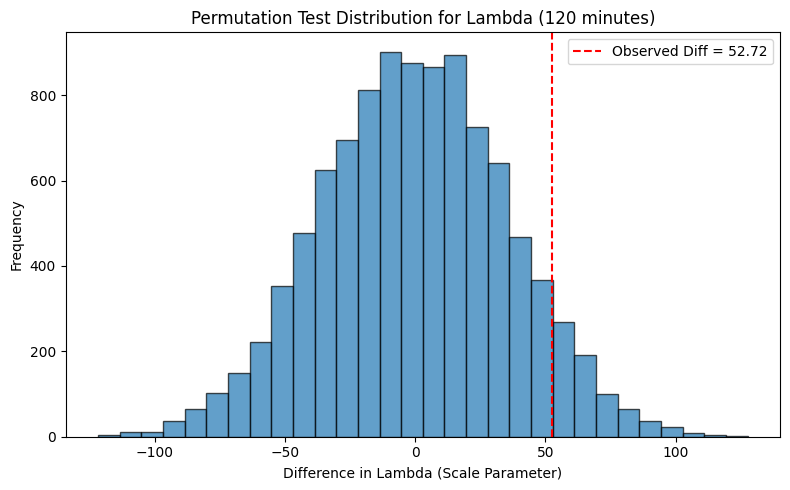

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# Function to perform permutation test on lambda (scale parameter of Exponential distribution)
def permutation_test_lambda(data_send, data_no_send, num_permutations=10000):
    # Fit Exponential distribution and get the scale (lambda) for both groups
    lambda_send = expon.fit(data_send, floc=0)[1]  # Scale (lambda) for sent data
    lambda_no_send = expon.fit(data_no_send, floc=0)[1]  # Scale (lambda) for unsent data
    
    # Calculate the observed difference in lambda
    observed_diff = lambda_send - lambda_no_send
    combined = np.concatenate([data_send, data_no_send])
    perm_diffs = []

    # Perform the permutation test
    for _ in range(num_permutations):
        np.random.shuffle(combined)
        perm_send = combined[:len(data_send)]
        perm_no_send = combined[len(data_send):]
        lambda_perm_send = expon.fit(perm_send, floc=0)[1]
        lambda_perm_no_send = expon.fit(perm_no_send, floc=0)[1]
        perm_diff = lambda_perm_send - lambda_perm_no_send
        perm_diffs.append(perm_diff)

    # Calculate p-value
    p_value = np.sum(np.abs(perm_diffs) >= np.abs(observed_diff)) / num_permutations
    return observed_diff, p_value, perm_diffs

# Run permutation test for lambda (scale parameter) for 30, 60, and 120 minutes
def run_permutation_tests_lambda(comparison_df, time_label):
    print(f"\nRunning Permutation Test for Lambda Difference ({time_label} minutes):")
    
    # Extract sent and unsent data
    data_send = comparison_df[f'jbsteps{time_label}_send'].dropna()
    data_no_send = comparison_df[f'jbsteps{time_label}_no_send'].dropna()
    
    # Perform permutation test
    observed_diff, p_value, perm_diffs = permutation_test_lambda(data_send, data_no_send)
    
    # Print results
    print(f"Observed Difference in Lambda: {observed_diff}")
    print(f"P-value: {p_value}")
    
    # Plot permutation test result
    plt.figure(figsize=(8, 5))
    plt.hist(perm_diffs, bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(observed_diff, color='red', linestyle='--', label=f'Observed Diff = {observed_diff:.2f}')
    plt.title(f'Permutation Test Distribution for Lambda ({time_label} minutes)')
    plt.xlabel('Difference in Lambda (Scale Parameter)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Load the datasets (same as before)
file_path_send = '../data/modified_data/Cleaned Dataset.csv'  
file_path_no_send = '../data/modified_data/Cleaned Unsent Dataset.csv'  

send_data = pd.read_csv(file_path_send)
no_send_data = pd.read_csv(file_path_no_send)

# Clean the column names by stripping leading/trailing spaces
send_data.columns = send_data.columns.str.strip()
no_send_data.columns = no_send_data.columns.str.strip()

# Convert 'sugg.decision.utime' to datetime format
send_data['sugg.decision.utime'] = pd.to_datetime(send_data['sugg.decision.utime'])
no_send_data['sugg.decision.utime'] = pd.to_datetime(no_send_data['sugg.decision.utime'])

# Fill NaN values in 'decision.index.nogap' with 0
send_data['decision.index.nogap'] = send_data['decision.index.nogap'].fillna(0)
no_send_data['decision.index.nogap'] = no_send_data['decision.index.nogap'].fillna(0)

# Calculate the tracked day as decision.index.nogap // 5 to integer round down
send_data['tracked_day'] = (send_data['decision.index.nogap'] // 5).astype(int)
no_send_data['tracked_day'] = (no_send_data['decision.index.nogap'] // 5).astype(int)

# Filter to only include the first 42 days
send_data = send_data[send_data['tracked_day'] <= 42]
no_send_data = no_send_data[no_send_data['tracked_day'] <= 42]

# Group by the tracked day and calculate the average step counts for jbsteps30, jbsteps60, and jbsteps120 for both send and no send data
# For 30 minutes
send_avg_steps_30 = send_data.groupby('tracked_day')['jbsteps30'].mean().reset_index()
no_send_avg_steps_30 = no_send_data.groupby('tracked_day')['jbsteps30'].mean().reset_index()

# For 60 minutes
send_avg_steps_60 = send_data.groupby('tracked_day')['jbsteps60'].mean().reset_index()
no_send_avg_steps_60 = no_send_data.groupby('tracked_day')['jbsteps60'].mean().reset_index()

# For 120 minutes
send_avg_steps_120 = send_data.groupby('tracked_day')['jbsteps120'].mean().reset_index()
no_send_avg_steps_120 = no_send_data.groupby('tracked_day')['jbsteps120'].mean().reset_index()

# Merge the data into a single DataFrame for comparison
comparison_df_30 = pd.merge(send_avg_steps_30, no_send_avg_steps_30, on='tracked_day', how='outer', suffixes=('_send', '_no_send'))
comparison_df_60 = pd.merge(send_avg_steps_60, no_send_avg_steps_60, on='tracked_day', how='outer', suffixes=('_send', '_no_send'))
comparison_df_120 = pd.merge(send_avg_steps_120, no_send_avg_steps_120, on='tracked_day', how='outer', suffixes=('_send', '_no_send'))

# Run permutation tests for lambda at 30, 60, and 120 minutes
run_permutation_tests_lambda(comparison_df_30, 30)
run_permutation_tests_lambda(comparison_df_60, 60)
run_permutation_tests_lambda(comparison_df_120, 120)
